In [2]:
import pandas as pd

# Load the CSV into a DataFrame
df = pd.read_csv('data/UsedCarsSA_Clean_EN.csv')


# View the first few rows
print(df.head())

       Make     Type  Year Origin   Color    Options  Engine_Size Fuel_Type  \
0  Chrysler     C300  2018  Saudi   Black       Full          5.7       Gas   
1    Nissan   Patrol  2016  Saudi   White       Full          4.8       Gas   
2    Nissan    Sunny  2019  Saudi  Silver   Standard          1.5       Gas   
3   Hyundai  Elantra  2019  Saudi    Grey   Standard          1.6       Gas   
4   Hyundai  Elantra  2019  Saudi  Silver  Semi Full          2.0       Gas   

   Gear_Type  Mileage  Region   Price  Negotiable  
0  Automatic   103000  Riyadh  114000       False  
1  Automatic     5448  Riyadh       0        True  
2  Automatic    72418  Riyadh   27500       False  
3  Automatic   114154  Riyadh   43000       False  
4  Automatic    41912  Riyadh   59500       False  


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8035 entries, 0 to 8034
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Make         8035 non-null   str    
 1   Type         8035 non-null   str    
 2   Year         8035 non-null   int64  
 3   Origin       8035 non-null   str    
 4   Color        8035 non-null   str    
 5   Options      8035 non-null   str    
 6   Engine_Size  8035 non-null   float64
 7   Fuel_Type    8035 non-null   str    
 8   Gear_Type    8035 non-null   str    
 9   Mileage      8035 non-null   int64  
 10  Region       8035 non-null   str    
 11  Price        8035 non-null   int64  
 12  Negotiable   8035 non-null   bool   
dtypes: bool(1), float64(1), int64(3), str(8)
memory usage: 761.3 KB


In [5]:
df.isnull().sum()

Make           0
Type           0
Year           0
Origin         0
Color          0
Options        0
Engine_Size    0
Fuel_Type      0
Gear_Type      0
Mileage        0
Region         0
Price          0
Negotiable     0
dtype: int64

In [6]:
df_filtered = df[df['Price']==0]
len(df_filtered )

2527

In [7]:
df_clean= df[df['Price']>0]

In [8]:
len(df_clean)

5508

In [9]:
df_clean['Make'].value_counts().head(10)

Make
Toyota       1262
Hyundai       719
Ford          512
Chevrolet     423
Nissan        362
Kia           268
Mercedes      256
GMC           246
Lexus         237
Mazda         139
Name: count, dtype: int64

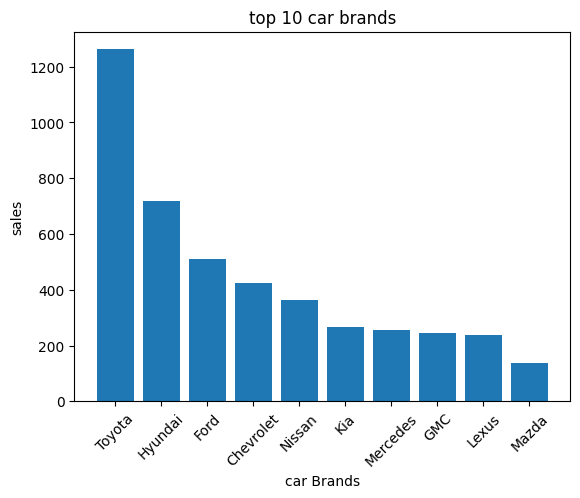

In [12]:
import matplotlib.pyplot as plt
top10 = df_clean['Make'].value_counts().head(10)
plt.bar(top10.index, top10.values)
plt.title('top 10 car brands')
plt.xlabel('car Brands')
plt.ylabel('sales')
plt.xticks(rotation=45)
plt.show()

In [19]:
avg_price = df_clean.groupby('Make')['Price'].mean().sort_values( ascending=False).head(10)
print(avg_price)

Make
Rolls-Royce     532500.000000
Bentley         393928.571429
Aston Martin    376666.666667
Ferrari         280000.000000
Land Rover      243553.333333
Maserati        216916.666667
Mercedes        171693.359375
Lexus           170692.827004
Porsche         160360.000000
Jaguar          139545.454545
Name: Price, dtype: float64


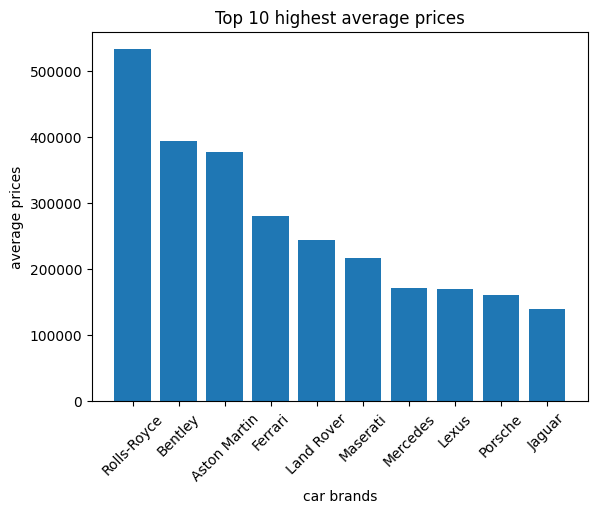

In [21]:
plt.bar(avg_price.index, avg_price.values)
plt.title('Top 10 highest average prices')
plt.xlabel('car brands')
plt.ylabel('average prices')
plt.xticks(rotation=45)
plt.show()

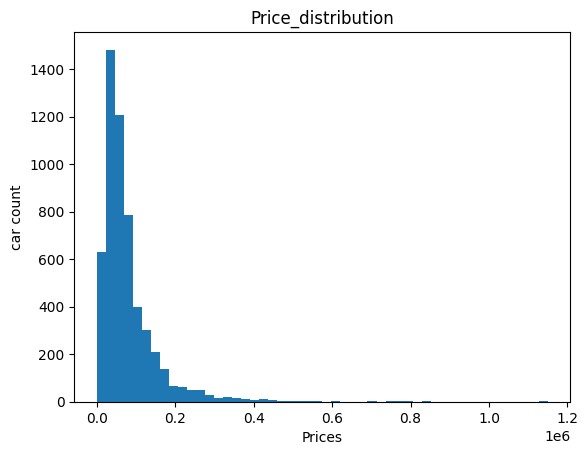

In [24]:
plt.hist(df_clean['Price'], bins=50)
plt.title('Price_distribution')
plt.xlabel('Prices')
plt.ylabel('car count')
plt.show()

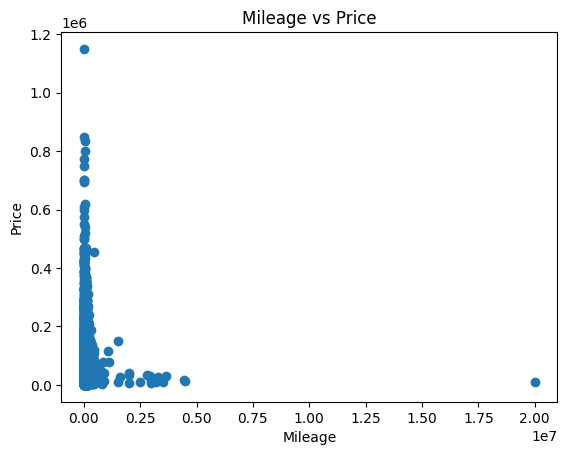

In [27]:
plt.scatter(df_clean['Mileage'], df_clean[ 'Price'])
plt.title('Mileage vs Price')
plt.xlabel('Mileage') 
plt.ylabel('Price')
plt.show()

In [28]:
most_expensive_by_region = df_clean.groupby('Region')['Price'].mean().sort_values( ascending=False)
print(most_expensive_by_region)

Region
Dammam            93695.482574
Riyadh            80994.703945
Jeddah            75394.803321
Qassim            74024.627329
Khobar            73245.428571
Sakaka            68400.000000
Makkah            67030.222222
Aseer             66654.561538
Al-Ahsa           66642.962025
Arar              64660.307692
Al-Jouf           61045.777778
Taef              60666.029412
Jazan             60618.759259
Wadi Dawasir      57800.000000
Al-Medina         57096.831395
Al-Baha           56375.000000
Qurayyat          55800.000000
Abha              55562.750000
Hafar Al-Batin    55512.750000
Hail              53284.969697
Najran            53271.913043
Besha             52333.333333
Yanbu             52047.619048
Tabouk            47299.927536
Jubail            46571.277778
Al-Namas          45666.666667
Sabya             26000.000000
Name: Price, dtype: float64


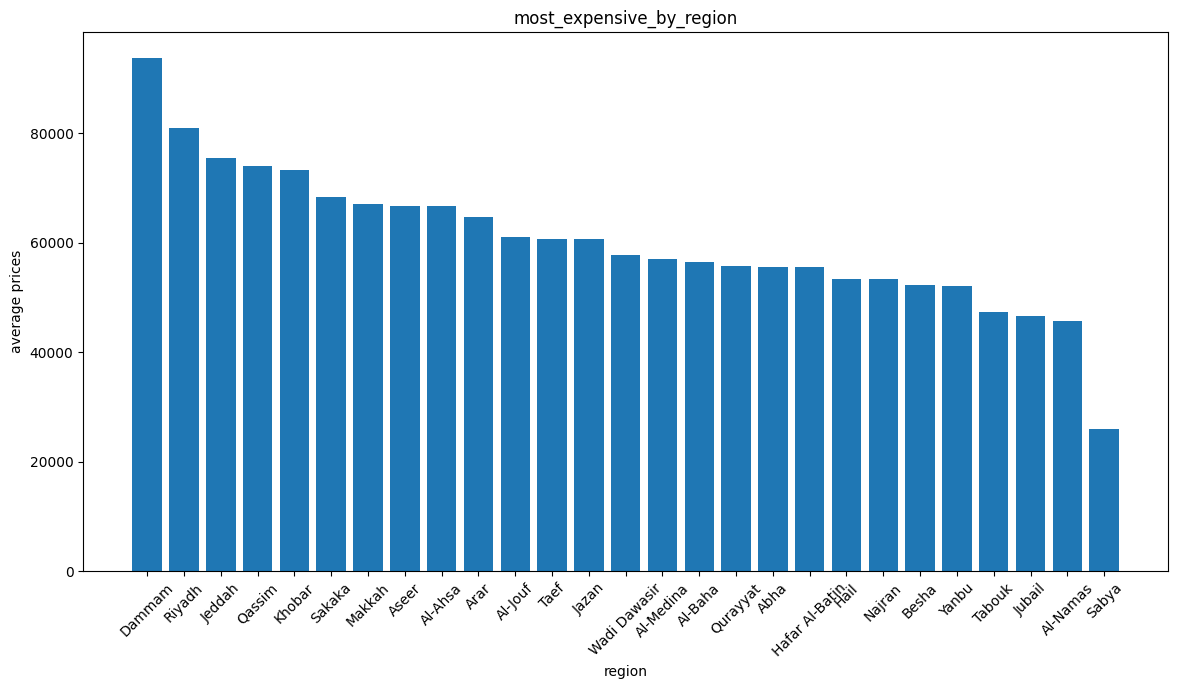

In [34]:
plt.figure(figsize=(14, 7))
plt.bar(most_expensive_by_region.index, most_expensive_by_region.values)
plt.title('most_expensive_by_region')
plt.xlabel('region')
plt.ylabel('average prices')
plt.xticks(rotation=45)
plt.show()

In [35]:
Price_by_Year = df_clean.groupby('Year')['Price'].mean().sort_index( ascending=True)
print(Price_by_Year)

Year
1963     22000.000000
1964     75000.000000
1970     45000.000000
1972     42000.000000
1978     23000.000000
1980    130000.000000
1981     30000.000000
1982     99000.000000
1983     12500.000000
1984     31000.000000
1985     30000.000000
1986      5500.000000
1987     20000.000000
1988     30000.000000
1989     36750.000000
1990     98000.000000
1991     42800.000000
1992     32750.000000
1993     19214.285714
1994     14300.000000
1995     15041.666667
1996      8900.000000
1997     20727.272727
1998     16363.636364
1999     21033.333333
2000     22750.000000
2001     16869.565217
2002     19736.842105
2003     25222.222222
2004     23939.285714
2005     28325.581395
2006     28090.909091
2007     29794.117647
2008     32227.272727
2009     35879.901961
2010     40630.952381
2011     43376.543210
2012     51719.125683
2013     63488.882736
2014     68028.448276
2015     77309.984293
2016     80665.654378
2017     80190.916006
2018     87771.088189
2019     99915.710983
2020 

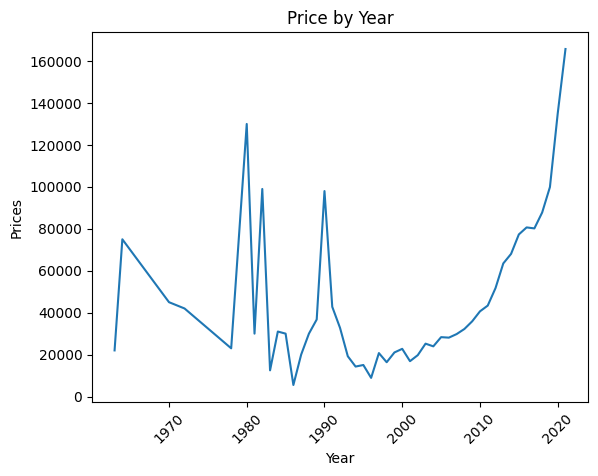

In [37]:
plt.plot(Price_by_Year.index, Price_by_Year.values)
plt.title('Price by Year')
plt.xlabel('Year')
plt.ylabel('Prices')
plt.xticks(rotation=45)
plt.show()